In [ ]:
from game_theory_experiments import (
    BasicGamesExperimentResult,
    BattleOfSexesActionsType,
    CheapTalkResponse,
    DictatorshipGameResult,
    PrisonersDilemmaActionsType,
    UltimatumGameResult,
)
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import pandas as pd

In [78]:
with open("../results/prisoners_dilemma_basic.json") as f:
    prisoners_dilemma_basic = BasicGamesExperimentResult[
        PrisonersDilemmaActionsType
    ].model_validate_json(f.read())
with open("../results/prisoners_dilemma_cheap_talk.json") as f:
    prisoners_dilemma_cheap_talk = BasicGamesExperimentResult[
        CheapTalkResponse[PrisonersDilemmaActionsType]
    ].model_validate_json(f.read())
with open("../results/battle_of_sexes_basic.json") as f:
    battle_of_sexes_basic = BasicGamesExperimentResult[
        BattleOfSexesActionsType
    ].model_validate_json(f.read())
with open("../results/battle_of_sexes_cheap_talk.json") as f:
    battle_of_sexes_cheap_talk = BasicGamesExperimentResult[
        CheapTalkResponse[BattleOfSexesActionsType]
    ].model_validate_json(f.read())
with open("../results/dictatorship_game.json") as f:
    dictatorship_game = DictatorshipGameResult.model_validate_json(f.read())
with open("../results/ultimatum_game.json") as f:
    ultimatum_game = UltimatumGameResult.model_validate_json(f.read())

In [79]:
def aggregate_results_basic[TAction: str](results: BasicGamesExperimentResult[TAction]):
    rows = [
        {"action_1": resp1.answer, "action_2": resp2.answer}
        if resp1.answer <= resp2.answer
        else {"action_1": resp2.answer, "action_2": resp1.answer}
        for result in results.results
        for resp1, resp2 in [result.responses]
    ]
    display(pd.DataFrame(rows).groupby(["action_1", "action_2"]).size().reset_index(name="count"))


print("Prisoner's Dilemma - Basic")
aggregate_results_basic(prisoners_dilemma_basic)
print()
print("Battle of the Sexes - Basic")
aggregate_results_basic(battle_of_sexes_basic)

Prisoner's Dilemma - Basic


,action_1,action_2,count
0,betray,betray,1
1,betray,stay silent,12
2,stay silent,stay silent,37



Battle of the Sexes - Basic


,action_1,action_2,count
0,Football,Football,2
1,Football,Opera,40
2,Opera,Opera,7


In [80]:
def aggregate_results_cheap_talk[TAction: str](
    results: BasicGamesExperimentResult[CheapTalkResponse[TAction]],
):
    rows = [
        {
            "coordinated_1": resp1.answer.coordinated_on_strategy,
            "coordinated_2": resp2.answer.coordinated_on_strategy,
            "final_1": resp1.answer.final_answer,
            "final_2": resp2.answer.final_answer,
        }
        for result in results.results
        for resp1, resp2 in [result.responses]
    ]
    display(pd.DataFrame(rows).groupby(["coordinated_1", "coordinated_2", "final_1", "final_2"]).size().reset_index(name="count"))

print("Prisoner's Dilemma - Cheap Talk")
aggregate_results_cheap_talk(prisoners_dilemma_cheap_talk)
print()
print("Battle of the Sexes - Cheap Talk")
aggregate_results_cheap_talk(battle_of_sexes_cheap_talk)   

Prisoner's Dilemma - Cheap Talk


,coordinated_1,coordinated_2,final_1,final_2,count
0,stay silent,stay silent,stay silent,betray,2
1,stay silent,stay silent,stay silent,stay silent,48



Battle of the Sexes - Cheap Talk


,coordinated_1,coordinated_2,final_1,final_2,count
0,Football,Football,Football,Football,6
1,Football,Opera,Football,Opera,19
2,Opera,Football,Opera,Football,1
3,Opera,Opera,Football,Opera,1
4,Opera,Opera,Opera,Opera,22


# Dictatorship and ultimatum game - our experiment


Dictatorship Game Distribution: μ = 1.91, σ = 0.63


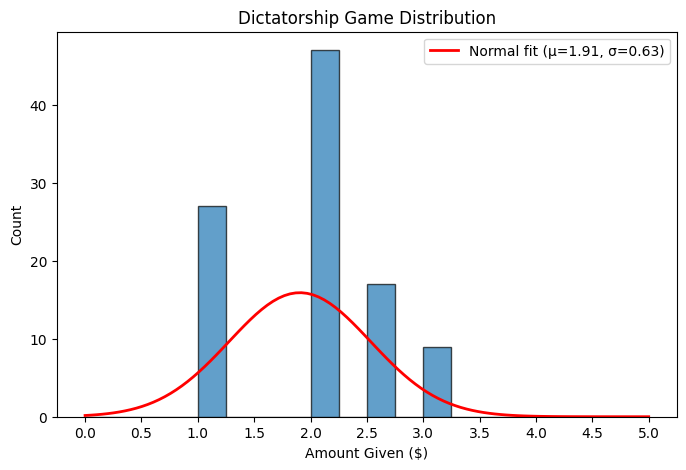

Ultimatum Game Offer Distribution: μ = 2.42, σ = 0.34


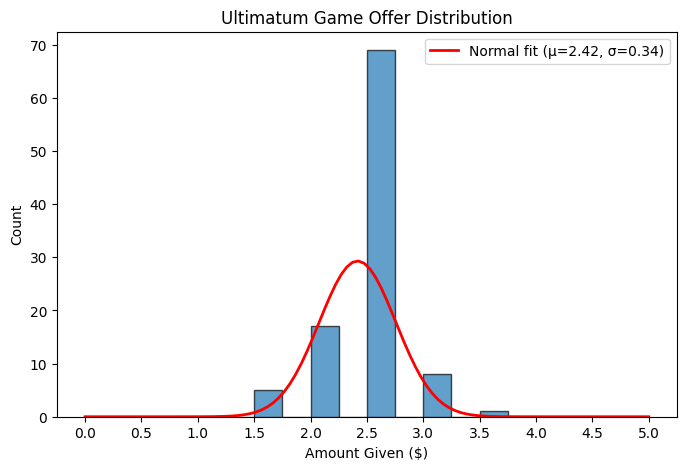

In [85]:
def plot_histogram_with_normal_fit(values: list[float], title: str):
    mu, std = norm.fit(values)
    print(f"{title}: μ = {mu:.2f}, σ = {std:.2f}")

    x = np.linspace(0, 5, 100)
    plt.figure(figsize=(8, 5))
    counts, edges, _ = plt.hist(values, bins=np.arange(0, 5.25, 0.25), edgecolor="black", alpha=0.7)
    pdf = norm.pdf(x, mu, std)
    bin_width = edges[1] - edges[0]
    plt.plot(x, pdf * len(values) * bin_width, "r-", linewidth=2, label=f"Normal fit (μ={mu:.2f}, σ={std:.2f})")
    plt.xlabel("Amount Given ($)")
    plt.ylabel("Count")
    plt.title(title)
    plt.xticks(np.arange(0, 5.25, 0.5))
    plt.legend()
    plt.show()


dictator_amounts = [result.response.amount_given for result in dictatorship_game.results]
plot_histogram_with_normal_fit(dictator_amounts, "Dictatorship Game Distribution")
ultimatum_offers = [result.propose_response.offer for result in ultimatum_game.results]
plot_histogram_with_normal_fit(ultimatum_offers, "Ultimatum Game Offer Distribution")

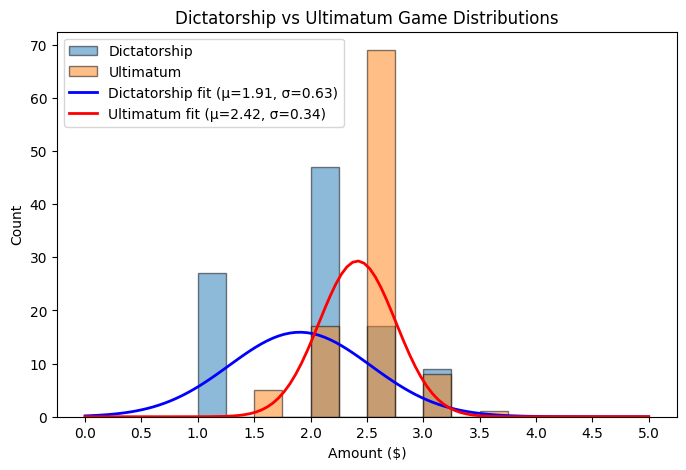

Dictatorship: μ = 1.91, σ = 0.63
Ultimatum:   μ = 2.42, σ = 0.34


In [86]:
# Compare distributions
mu_dict, std_dict = norm.fit(dictator_amounts)
mu_ulti, std_ulti = norm.fit(ultimatum_offers)

x = np.linspace(0, 5, 100)
bin_width = 0.25

plt.figure(figsize=(8, 5))
plt.hist(dictator_amounts, bins=np.arange(0, 5.25, 0.25), alpha=0.5, label="Dictatorship", edgecolor="black")
plt.hist(ultimatum_offers, bins=np.arange(0, 5.25, 0.25), alpha=0.5, label="Ultimatum", edgecolor="black")
plt.plot(x, norm.pdf(x, mu_dict, std_dict) * len(dictator_amounts) * bin_width, "b-", linewidth=2, label=f"Dictatorship fit (μ={mu_dict:.2f}, σ={std_dict:.2f})")
plt.plot(x, norm.pdf(x, mu_ulti, std_ulti) * len(ultimatum_offers) * bin_width, "r-", linewidth=2, label=f"Ultimatum fit (μ={mu_ulti:.2f}, σ={std_ulti:.2f})")
plt.xlabel("Amount ($)")
plt.ylabel("Count")
plt.title("Dictatorship vs Ultimatum Game Distributions")
plt.xticks(np.arange(0, 5.25, 0.5))
plt.legend()
plt.show()

print(f"Dictatorship: μ = {mu_dict:.2f}, σ = {std_dict:.2f}")
print(f"Ultimatum:   μ = {mu_ulti:.2f}, σ = {std_ulti:.2f}")

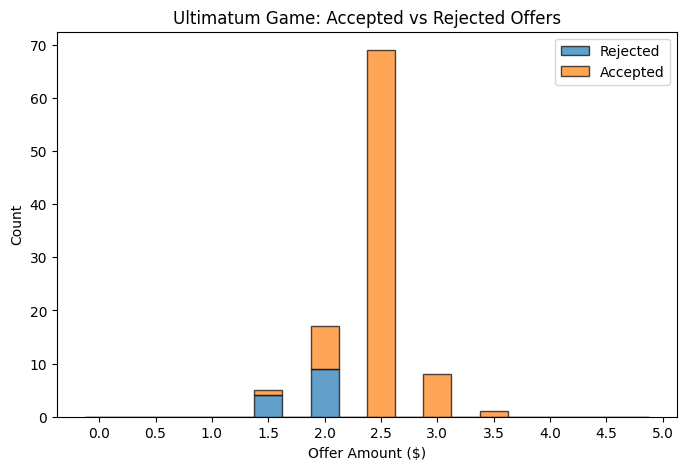

In [87]:
# Ultimatum game: offers accepted vs rejected
offers = [result.propose_response.offer for result in ultimatum_game.results]
decisions = [result.respond_response.decision for result in ultimatum_game.results]

accepted = [o for o, d in zip(offers, decisions) if d == "accept"]
rejected = [o for o, d in zip(offers, decisions) if d == "reject"]

plt.figure(figsize=(8, 5))
plt.hist([rejected, accepted], bins=np.arange(0, 5.25, 0.25), stacked=True, edgecolor="black", alpha=0.7, label=["Rejected", "Accepted"],align='left')
plt.xlabel("Offer Amount ($)")
plt.ylabel("Count")
plt.title("Ultimatum Game: Accepted vs Rejected Offers")
plt.xticks(np.arange(0, 5.25, 0.5))
plt.legend()
plt.show()

# Dictatorship and ultimatum games - comparison to original paper

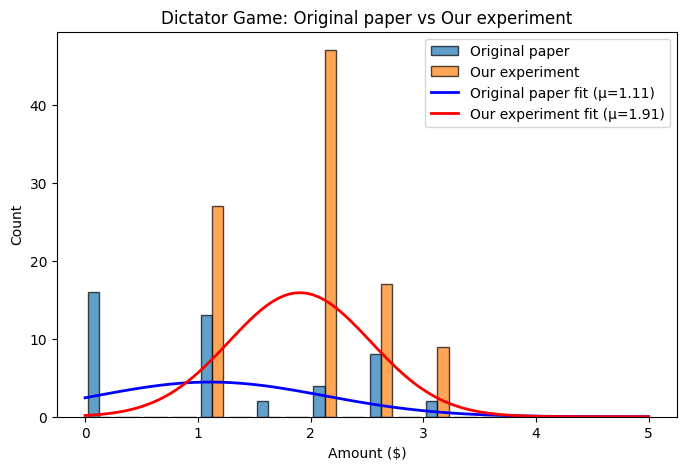

Original paper: μ = 1.11, σ = 1.01
Our experiment: μ = 1.91, σ = 0.63


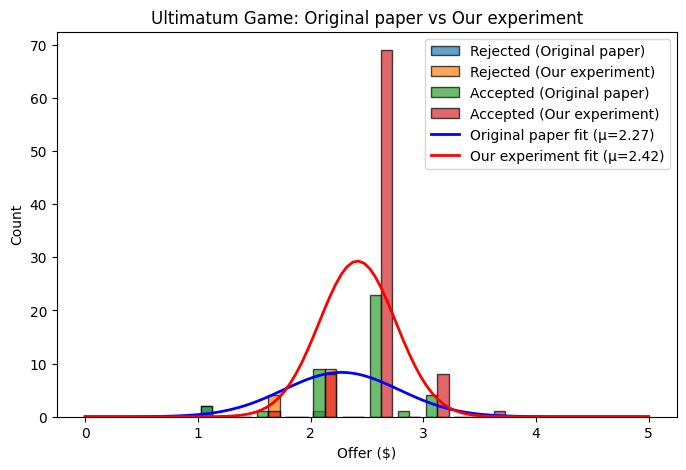

Original paper: μ = 2.27, σ = 0.51
Our experiment: μ = 2.42, σ = 0.34


In [88]:
original_data_df = pd.read_csv("dictator_game_original_paper_data.csv")
pay_data_df = original_data_df[original_data_df["Pay/No Pay"] == "Pay"]
dictator_game_df = pay_data_df[pay_data_df["Game"] == "Dictator"]
ultimatum_game_df = pay_data_df[pay_data_df["Game"] == "Ultimatum"]

original_dictator = dictator_game_df["Value"].tolist()
original_ulti_accept = ultimatum_game_df[ultimatum_game_df["Rejected"] == False]["Value"].tolist()
original_ulti_reject = ultimatum_game_df[ultimatum_game_df["Rejected"] == True]["Value"].tolist()

# Dictator Game: Original paper vs Our experiment
fig, ax = plt.subplots(figsize=(8, 5))
bins = np.arange(0, 5.25, 0.25)
ax.hist([original_dictator, dictator_amounts], bins=bins, histtype="bar", alpha=0.7, edgecolor="black", label=["Original paper", "Our experiment"])

mu_orig, std_orig = norm.fit(original_dictator)
mu_exp, std_exp = norm.fit(dictator_amounts)
x = np.linspace(0, 5, 100)
bin_width = 0.25
ax.plot(x, norm.pdf(x, mu_orig, std_orig) * len(original_dictator) * bin_width, "b-", linewidth=2, label=f"Original paper fit (μ={mu_orig:.2f})")
ax.plot(x, norm.pdf(x, mu_exp, std_exp) * len(dictator_amounts) * bin_width, "r-", linewidth=2, label=f"Our experiment fit (μ={mu_exp:.2f})")

ax.set_xlabel("Amount ($)")
ax.set_ylabel("Count")
ax.set_title("Dictator Game: Original paper vs Our experiment")
ax.legend()
plt.show()

print(f"Original paper: μ = {mu_orig:.2f}, σ = {std_orig:.2f}")
print(f"Our experiment: μ = {mu_exp:.2f}, σ = {std_exp:.2f}")

# Ultimatum Game: Original paper vs Our experiment (Accepted vs Rejected)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist([original_ulti_reject, rejected], bins=bins, histtype="bar", alpha=0.7, edgecolor="black", label=["Rejected (Original paper)", "Rejected (Our experiment)"])
ax.hist([original_ulti_accept, accepted], bins=bins, histtype="bar", alpha=0.7, edgecolor="black", label=["Accepted (Original paper)", "Accepted (Our experiment)"])

mu_orig, std_orig = norm.fit(original_ulti_accept + original_ulti_reject)
mu_exp, std_exp = norm.fit(ultimatum_offers)
ax.plot(x, norm.pdf(x, mu_orig, std_orig) * len(original_ulti_accept + original_ulti_reject) * bin_width, "b-", linewidth=2, label=f"Original paper fit (μ={mu_orig:.2f})")
ax.plot(x, norm.pdf(x, mu_exp, std_exp) * len(ultimatum_offers) * bin_width, "r-", linewidth=2, label=f"Our experiment fit (μ={mu_exp:.2f})")

ax.set_xlabel("Offer ($)")
ax.set_ylabel("Count")
ax.set_title("Ultimatum Game: Original paper vs Our experiment")
ax.legend()
plt.show()

print(f"Original paper: μ = {mu_orig:.2f}, σ = {std_orig:.2f}")
print(f"Our experiment: μ = {mu_exp:.2f}, σ = {std_exp:.2f}")